# JAX forward model

This notebook tests and demonstrates `albert_mobley_jax.py` — the JAX-based thin layer over the Albert & Mobley (2003) forward model.

## Two entry points

| Function | Input | JIT / grad / vmap? | Use case |
|---|---|---|---|
| `forward(params, pre)` | lmfit Parameters | No | Drop-in replacement for `albert_mobley.forward()` |
| `make_forward_vec(names, pre)` | 1-D JAX array | Yes | JIT compilation, Jacobians, batched inversion |

`forward()` exists so existing code that already builds lmfit Parameters objects keeps working without changes. `make_forward_vec()` returns a function that JAX can trace, compile, and differentiate.

## Contents
1. Setup — params, wavelengths, precompute
2. Numerical equivalence test — JAX vs NumPy forward
3. JIT compilation — fair benchmark: NumPy unprecomputed / precomputed / JAX JIT
4. Jacobian — shape and finite-difference check
5. vmap — batched forward over many parameter sets

In [1]:
import numpy as np
import lmfit
import jax
import jax.numpy as jnp
import timeit
from matplotlib import pyplot as plt

from bio_optics.water.reflectance import albert_mobley, albert_mobley_jax
from bio_optics.helper import resampling

## 1  Setup

In [2]:
wavelengths = np.arange(400, 900, dtype=float)

In [3]:
# Build a default parameter set (matches params.yaml defaults)
params = lmfit.Parameters()

# Water constituents
params.add('C_0',  value=1.0,   vary=False)
params.add('C_1',  value=0.0,   vary=False)
params.add('C_2',  value=0.0,   vary=False)
params.add('C_3',  value=0.0,   vary=False)
params.add('C_4',  value=0.0,   vary=False)
params.add('C_5',  value=0.0,   vary=False)
params.add('C_Y',  value=0.3,   vary=False)
params.add('C_X',  value=2.0,   vary=False)
params.add('C_Mie',value=1.0,   vary=False)

# Bottom
params.add('zB',   value=5.0,   vary=False)
params.add('f_0',  value=0.5,   vary=False)
params.add('f_1',  value=0.5,   vary=False)
params.add('f_2',  value=0.0,   vary=False)
params.add('f_3',  value=0.0,   vary=False)
params.add('f_4',  value=0.0,   vary=False)
params.add('f_5',  value=0.0,   vary=False)
params.add('B_0',  value=1/np.pi, vary=False)
params.add('B_1',  value=1/np.pi, vary=False)
params.add('B_2',  value=1/np.pi, vary=False)
params.add('B_3',  value=1/np.pi, vary=False)
params.add('B_4',  value=1/np.pi, vary=False)
params.add('B_5',  value=1/np.pi, vary=False)

# Backscattering
params.add('bb_phy_spec',    value=0.001,  vary=False)
params.add('bb_Mie_spec',    value=0.0042, vary=False)
params.add('bb_X_spec',      value=0.0086, vary=False)
params.add('b_X_norm_factor',value=1.0,    vary=False)

# Absorption
params.add('S',                  value=0.014,  vary=False)
params.add('S_NAP',              value=0.011,  vary=False)
params.add('K',                  value=0.0,    vary=False)
params.add('lambda_0',           value=440.0,  vary=False)
params.add('lambda_S',           value=500.0,  vary=False)
params.add('n',                  value=0.0,    vary=False)
params.add('a_NAP_spec_lambda_0',value=0.041,  vary=False)

# Sub-surface reflectance model
params.add('A',       value=0.0006,  vary=False)
params.add('B',       value=-0.37,   vary=False)
params.add('n1',      value=1.0,     vary=False)
params.add('n2',      value=1.33,    vary=False)
params.add('kappa_0', value=1.0546,  vary=False)
params.add('fresh',   value=False,   vary=False)

# Temperature
params.add('T_W',   value=20.0, vary=False)
params.add('T_W_0', value=20.0, vary=False)

# Geometry
params.add('theta_sun',  value=np.pi/6, vary=False)
params.add('theta_view', value=np.radians(2),     vary=False)

print(f"Parameters defined: {len(params)}")

Parameters defined: 43


In [4]:
# Precompute all static spectral lookup tables once
pre = albert_mobley_jax.precompute(wavelengths, fresh=False)

print("Precomputed keys:", list(pre.keys()))
for k, v in pre.items():
    print(f"  {k}: shape={v.shape}, dtype={v.dtype}")

Precomputed keys: ['wavelengths', 'a_w', 'da_w_div_dT', 'a_i_spec', 'b_phy_norm', 'bb_w', 'b_X_norm', 'R_b_i']
  wavelengths: shape=(500,), dtype=float64
  a_w: shape=(500,), dtype=float64
  da_w_div_dT: shape=(500,), dtype=float64
  a_i_spec: shape=(500, 6), dtype=float64
  b_phy_norm: shape=(500,), dtype=float64
  bb_w: shape=(500,), dtype=float64
  b_X_norm: shape=(500,), dtype=float64
  R_b_i: shape=(500, 6), dtype=float64


## 2  Numerical equivalence test

The JAX forward model should produce values identical (within float64 precision) to the NumPy implementation in `albert_mobley.forward()`.

In [5]:
# NumPy reference
Rrs_np = albert_mobley.forward(params, wavelengths)

# JAX forward (convenience wrapper)
Rrs_jax = np.array(albert_mobley_jax.forward(params, pre))

max_abs_diff = np.max(np.abs(Rrs_np - Rrs_jax))
rel_diff = np.max(np.abs((Rrs_np - Rrs_jax) / (np.abs(Rrs_np) + 1e-12)))

print(f"Max absolute difference: {max_abs_diff:.2e}")
print(f"Max relative difference: {rel_diff:.2e}")
assert max_abs_diff < 1e-10, "JAX and NumPy outputs diverge!"
print("PASSED: outputs match within 1e-10")

Max absolute difference: 1.39e-17
Max relative difference: 1.04e-15
PASSED: outputs match within 1e-10


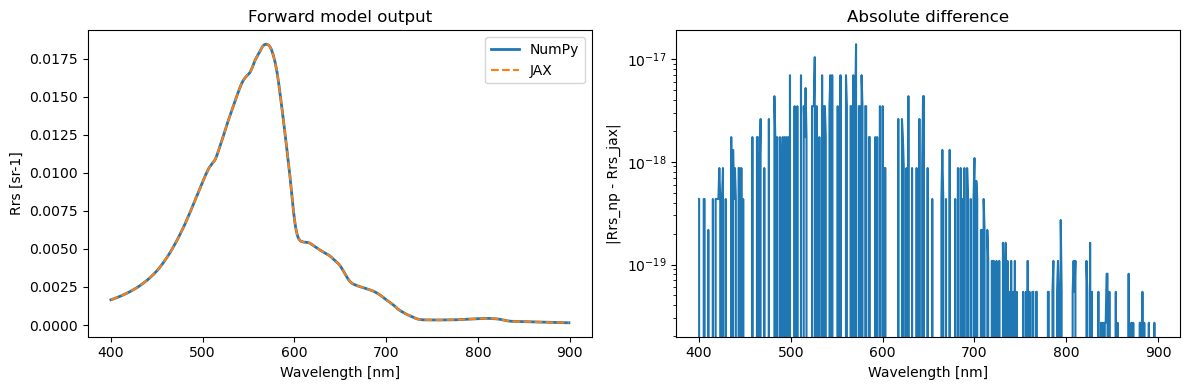

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(wavelengths, Rrs_np,  label='NumPy', lw=2)
axes[0].plot(wavelengths, Rrs_jax, label='JAX',   lw=1.5, ls='--')
axes[0].set_xlabel('Wavelength [nm]')
axes[0].set_ylabel('Rrs [sr-1]')
axes[0].set_title('Forward model output')
axes[0].legend()

axes[1].plot(wavelengths, np.abs(Rrs_np - Rrs_jax))
axes[1].set_xlabel('Wavelength [nm]')
axes[1].set_ylabel('|Rrs_np - Rrs_jax|')
axes[1].set_title('Absolute difference')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## 3  JIT compilation — fair benchmark

`make_forward_vec` returns a function over a flat parameter vector — this is the version that can be JIT-compiled.

The first call traces and compiles (slow). Subsequent calls execute the compiled XLA program (fast).

To be fair to NumPy, we benchmark it both ways:
- **unprecomputed** — resampling on every call (the naïve baseline)
- **precomputed** — same lookup tables passed in as arrays, so only arithmetic remains (the fair baseline, apples-to-apples with JAX)

In [7]:
# Names and values for all parameters
all_names = list(params.keys())
params_vec_full = jnp.array([float(params[k]) for k in all_names])

f_vec = albert_mobley_jax.make_forward_vec(all_names, pre)
f_jit = jax.jit(f_vec)

print("Parameter vector length:", len(params_vec_full))

Parameter vector length: 43


In [8]:
# Warm-up / trace (first call compiles)
Rrs_jit = f_jit(params_vec_full).block_until_ready()
print(f"JIT output matches NumPy: {np.allclose(np.array(Rrs_jit), Rrs_np, atol=1e-10)}")

JIT output matches NumPy: True


In [9]:
# Precomputed numpy arrays for the fair baseline
a_w_res        = resampling.resample_a_w(wavelengths)
da_w_div_dT_res= resampling.resample_da_w_div_dT(wavelengths)
a_i_spec_res   = resampling.resample_a_i_spec(wavelengths)
b_phy_norm_res = resampling.resample_b_phy_norm(wavelengths)
bb_w_res       = resampling.resample_bb_w(wavelengths)
R_b_i_res      = resampling.resample_R_b_i(wavelengths)

N = 200

t_np_raw = timeit.timeit(
    lambda: albert_mobley.forward(params, wavelengths),
    number=N
) / N * 1e3

t_np_pre = timeit.timeit(
    lambda: albert_mobley.forward(
        params, wavelengths,
        a_w_res=a_w_res, da_w_div_dT_res=da_w_div_dT_res,
        a_i_spec_res=a_i_spec_res, b_phy_norm_res=b_phy_norm_res,
        bb_w_res=bb_w_res, R_b_i_res=R_b_i_res,
    ),
    number=N
) / N * 1e3

t_jax = timeit.timeit(
    lambda: f_jit(params_vec_full).block_until_ready(),
    number=N
) / N * 1e3

print(f"NumPy (no precompute):    {t_np_raw:.3f} ms / call")
print(f"NumPy (precomputed):      {t_np_pre:.3f} ms / call   ← fair baseline")
print(f"JAX JIT:                  {t_jax:.3f} ms / call")
print(f"Speedup vs fair baseline: {t_np_pre / t_jax:.1f}x")

NumPy (no precompute):    595.155 ms / call
NumPy (precomputed):      0.936 ms / call   ← fair baseline
JAX JIT:                  0.140 ms / call
Speedup vs fair baseline: 6.7x


## 4  Jacobian

`jax.jacobian` computes the full $\partial \text{Rrs} / \partial \mathbf{p}$ matrix in one call. The output has shape `(n_wavelengths, n_params)`. This replaces the hand-written `d*_div_dp` functions in `attenuation.py`, `absorption.py`, etc.

In [10]:
J = jax.jacobian(f_jit)(params_vec_full)
print(f"Jacobian shape: {J.shape}  (n_wavelengths x n_params)")
assert J.shape == (len(wavelengths), len(all_names))

Jacobian shape: (500, 43)  (n_wavelengths x n_params)


In [11]:
# Finite-difference check for a few parameters.
# We normalize error by the column maximum to avoid false failures at
# wavelengths where Rrs ≈ 0 (e.g. deep-water near-IR).
eps = 1e-5
check_params = ['C_0', 'C_Y', 'zB']

for name in check_params:
    idx = all_names.index(name)

    v_plus  = params_vec_full.at[idx].add( eps)
    v_minus = params_vec_full.at[idx].add(-eps)
    fd = (np.array(f_jit(v_plus)) - np.array(f_jit(v_minus))) / (2 * eps)

    ad = np.array(J[:, idx])
    abs_err = np.max(np.abs(fd - ad))
    rel_err = abs_err / (np.max(np.abs(ad)) + 1e-12)
    print(f"  d(Rrs)/d({name}): abs err = {abs_err:.2e}, rel err (col-max-norm) = {rel_err:.2e}")
    assert rel_err < 1e-4, f"Jacobian mismatch for {name}"

  d(Rrs)/d(C_0): abs err = 7.49e-13, rel err (col-max-norm) = 3.41e-10
  d(Rrs)/d(C_Y): abs err = 1.36e-11, rel err (col-max-norm) = 4.03e-10
  d(Rrs)/d(zB): abs err = 5.62e-13, rel err (col-max-norm) = 1.10e-10


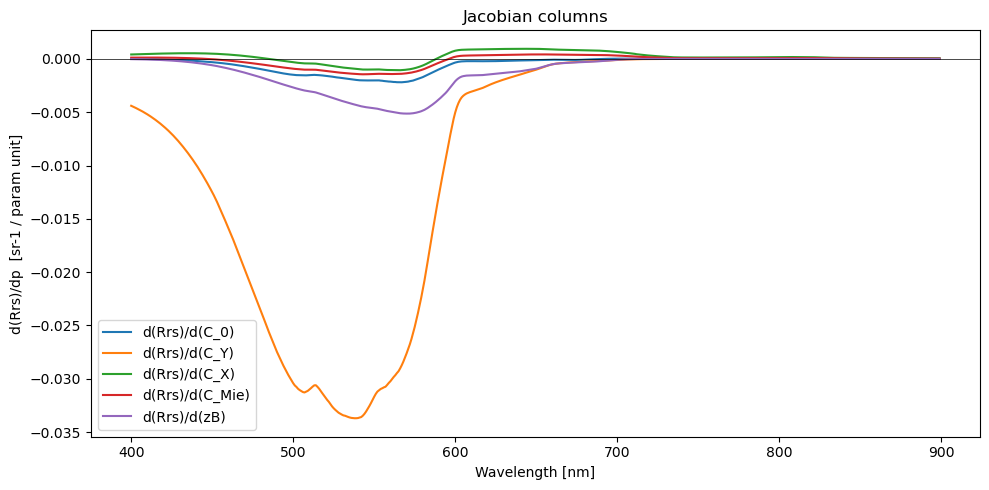

In [12]:
# Plot Jacobian columns for the most sensitive parameters
fig, ax = plt.subplots(figsize=(10, 5))
for name in ['C_0', 'C_Y', 'C_X', 'C_Mie', 'zB']:
    idx = all_names.index(name)
    ax.plot(wavelengths, J[:, idx], label=f'd(Rrs)/d({name})')

ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('d(Rrs)/dp  [sr-1 / param unit]')
ax.set_title('Jacobian columns')
ax.legend()
plt.tight_layout()
plt.show()

## 5  vmap — batched forward

`jax.vmap` vectorizes the forward call over a batch of parameter vectors. This is the foundation for batched inversion over many pixels.

In [13]:
n_pixels = 100
rng = np.random.default_rng(42)

# Randomly perturb a few parameters around the base values
params_batch = np.tile(params_vec_full, (n_pixels, 1))
for name, scale in [('C_0', 3.0), ('C_Y', 0.3), ('zB', 8.0)]:
    idx = all_names.index(name)
    params_batch[:, idx] = np.abs(rng.normal(float(params[name]), scale, n_pixels))

params_batch = jnp.array(params_batch)
print(f"Batch shape: {params_batch.shape}  (n_pixels x n_params)")

Batch shape: (100, 43)  (n_pixels x n_params)


In [14]:
f_batch = jax.jit(jax.vmap(f_vec))

# Warm-up
Rrs_batch = f_batch(params_batch).block_until_ready()
print(f"Batch output shape: {Rrs_batch.shape}  (n_pixels x n_wavelengths)")

t_batch = timeit.timeit(
    lambda: f_batch(params_batch).block_until_ready(),
    number=50
) / 50 * 1e3

print(f"vmap batch ({n_pixels} pixels): {t_batch:.2f} ms total  |  {t_batch/n_pixels:.3f} ms/pixel")

Batch output shape: (100, 500)  (n_pixels x n_wavelengths)
vmap batch (100 pixels): 4.33 ms total  |  0.043 ms/pixel


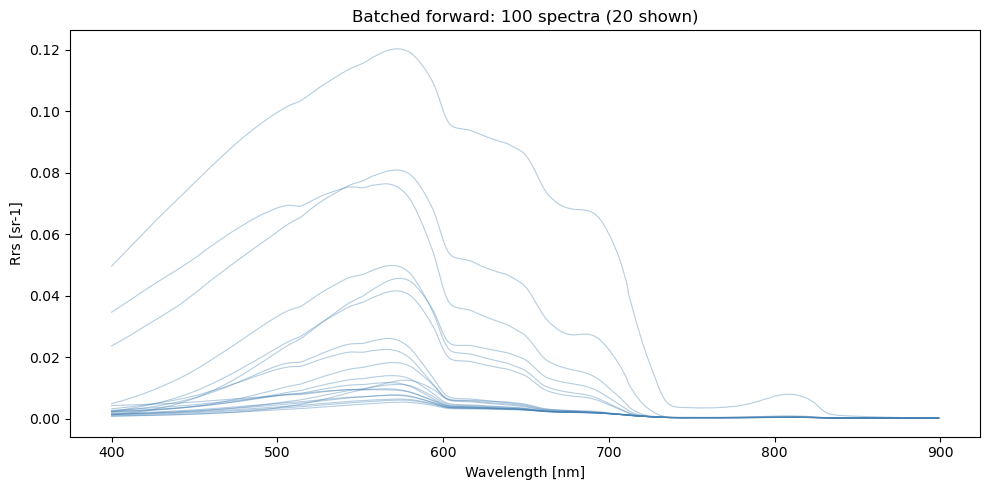

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(min(20, n_pixels)):
    ax.plot(wavelengths, np.array(Rrs_batch[i]), alpha=0.4, lw=0.8, color='steelblue')

ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Rrs [sr-1]')
ax.set_title(f'Batched forward: {n_pixels} spectra (20 shown)')
plt.tight_layout()
plt.show()

## 6  Optical property components

Absorption and backscattering broken down by constituent,
computed from the same parameter set used throughout this notebook.

- **Absorption**: pure water $a_w$ · phytoplankton $a_{ph}$ · CDOM $a_Y$ · NAP $a_{NAP}$
- **Backscattering**: pure water $b_{b,w}$ · phytoplankton $b_{b,phy}$ · type I NAP $b_{b,X}$ · type II Mie $b_{b,Mie}$

In [16]:
from bio_optics.water import absorption_jax, backscattering_jax, attenuation_jax

p   = {k: float(params[k]) for k in params}
wl  = pre['wavelengths']

# Absorption components
C_i     = jnp.array([p['C_0'], p['C_1'], p['C_2'], p['C_3'], p['C_4'], p['C_5']])
a_w_c   = pre['a_w'] + (p['T_W'] - p['T_W_0']) * pre['da_w_div_dT']
a_ph_c  = absorption_jax.a_ph(C_i, pre['a_i_spec'])
a_Y_c   = absorption_jax.a_Y(p['C_Y'], p['S'], p['lambda_0'], wl, K=p['K'])
a_NAP_c = absorption_jax.a_NAP(
    p['C_X'], p['C_Mie'], p['S_NAP'], p['lambda_0'], wl,
    a_NAP_spec_lambda_0=p['a_NAP_spec_lambda_0'])
a_total = a_w_c + a_ph_c + a_Y_c + a_NAP_c

# Backscattering components
C_phy    = sum(p[f'C_{j}'] for j in range(6))
bb_w_c   = pre['bb_w']
bb_phy_c = backscattering_jax.bb_phy(C_phy, p['bb_phy_spec'], pre['b_phy_norm'])
bb_X_c   = backscattering_jax.bb_X(p['C_X'], p['bb_X_spec'], pre['b_X_norm'])
bb_Mie_c = backscattering_jax.bb_Mie(
    p['C_Mie'], p['bb_Mie_spec'], p['lambda_S'], p['n'], wl)
bb_total = bb_w_c + bb_phy_c + bb_X_c + bb_Mie_c

# Single-scattering albedo
ob    = attenuation_jax.omega_b(a_total, bb_total)
wl_np = np.array(wl)

print(f'  a_w   @ 440 nm : {float(a_w_c[40]):.4f}  m-1')
print(f'  a_ph  @ 440 nm : {float(a_ph_c[40]):.4f}  m-1')
print(f'  a_Y   @ 440 nm : {float(a_Y_c[40]):.4f}  m-1')
print(f'  a_NAP @ 440 nm : {float(a_NAP_c[40]):.4f}  m-1')
print()
print(f'  bb_w  @ 550 nm : {float(bb_w_c[150]):.5f} m-1')
print(f'  bb_phy@ 550 nm : {float(bb_phy_c[150]):.5f} m-1')
print(f'  bb_X  @ 550 nm : {float(bb_X_c[150]):.5f} m-1')
print(f'  bb_Mie@ 550 nm : {float(bb_Mie_c[150]):.5f} m-1')

  a_w   @ 440 nm : 0.0064  m-1
  a_ph  @ 440 nm : 0.0335  m-1
  a_Y   @ 440 nm : 0.3000  m-1
  a_NAP @ 440 nm : 0.1230  m-1

  bb_w  @ 550 nm : 0.00095 m-1
  bb_phy@ 550 nm : 0.00094 m-1
  bb_X  @ 550 nm : 0.01720 m-1
  bb_Mie@ 550 nm : 0.00420 m-1


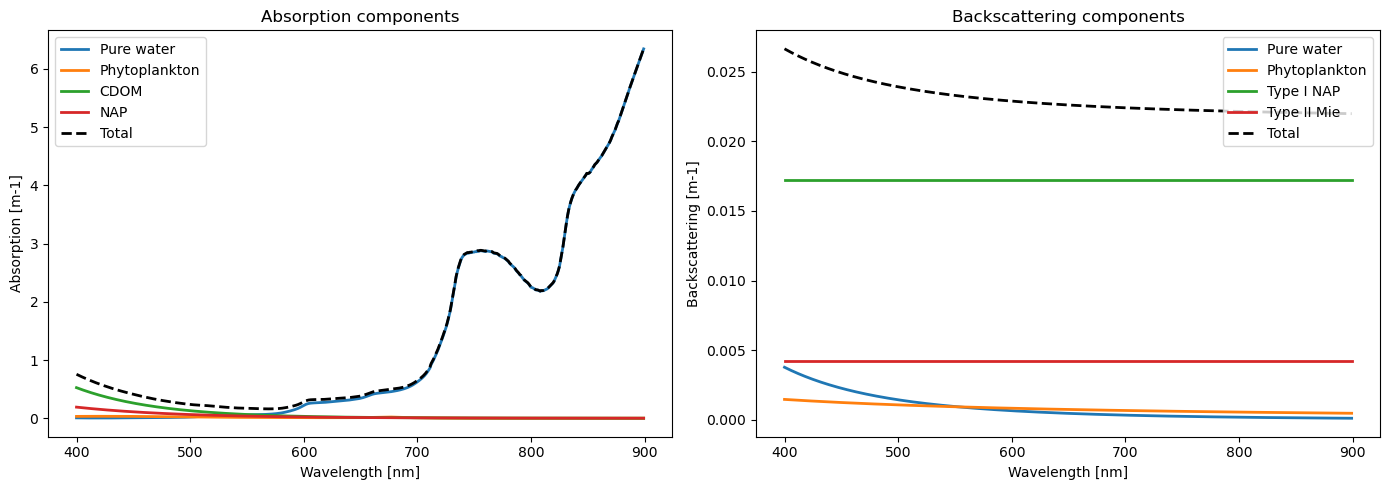

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for arr, label in [
    (np.array(a_w_c),   'Pure water'),
    (np.array(a_ph_c),  'Phytoplankton'),
    (np.array(a_Y_c),   'CDOM'),
    (np.array(a_NAP_c), 'NAP'),
]:
    ax.plot(wl_np, np.clip(arr, 1e-6, None), label=label, lw=2)
ax.plot(wl_np, np.array(a_total), label='Total', lw=2, ls='--', color='k')
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Absorption [m-1]')
ax.set_title('Absorption components')
ax.legend()

ax = axes[1]
for arr, label in [
    (np.array(bb_w_c),   'Pure water'),
    (np.array(bb_phy_c), 'Phytoplankton'),
    (np.array(bb_X_c),   'Type I NAP'),
    (np.array(bb_Mie_c), 'Type II Mie'),
]:
    ax.plot(wl_np, np.clip(arr, 1e-8, None), label=label, lw=2)
ax.plot(wl_np, np.array(bb_total), label='Total', lw=2, ls='--', color='k')
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Backscattering [m-1]')
ax.set_title('Backscattering components')
ax.legend()

plt.tight_layout()
plt.show()

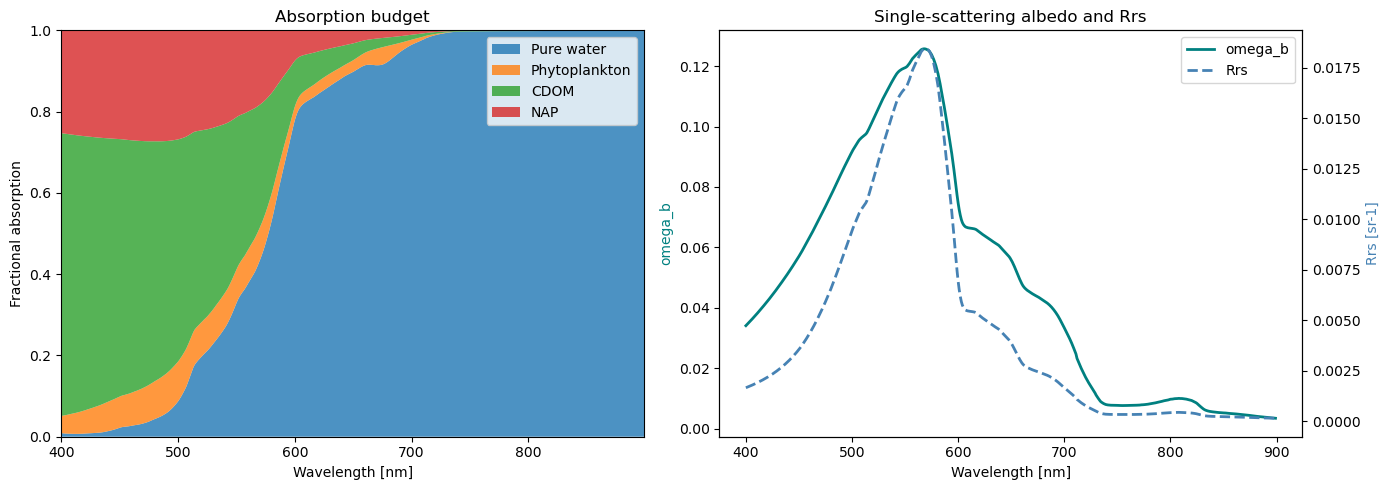

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absorption fractional budget
a_tot_np = np.array(a_total)
ax = axes[0]
bottom = np.zeros_like(wl_np)
for label, arr in [
    ('Pure water',    np.array(a_w_c)),
    ('Phytoplankton', np.array(a_ph_c)),
    ('CDOM',          np.array(a_Y_c)),
    ('NAP',           np.array(a_NAP_c)),
]:
    frac = arr / a_tot_np
    ax.fill_between(wl_np, bottom, bottom + frac, label=label, alpha=0.8)
    bottom += frac
ax.set_ylim(0, 1)
ax.set_xlim(wl_np[0], wl_np[-1])
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Fractional absorption')
ax.set_title('Absorption budget')
ax.legend(loc='upper right')

# Single-scattering albedo and Rrs
ax = axes[1]
l1, = ax.plot(wl_np, np.array(ob), color='teal', lw=2, label='omega_b')
ax2 = ax.twinx()
l2, = ax2.plot(wl_np, Rrs_jax, color='steelblue', lw=2, ls='--', label='Rrs')
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('omega_b', color='teal')
ax2.set_ylabel('Rrs [sr-1]', color='steelblue')
ax.set_title('Single-scattering albedo and Rrs')
ax.legend(handles=[l1, l2], loc='upper right')

plt.tight_layout()
plt.show()

## 7  3C coupled model — surface glint parameters

`albert_mobley_3C_jax` adds a sky-glint surface term to the water-leaving Rrs:

$$R_{rs} = R_{rs,water} + \rho_L \frac{f_{d,d}\, g_{dd}\, E_{d,d} + f_{d,s}(g_{d,sr}\, E_{d,sr} + g_{d,sa}\, E_{d,sa})}{f_{d,d}\, E_{d,d} + f_{d,s}(E_{d,sr} + E_{d,sa})} + d_r + \text{offset}$$

The irradiance spectra $E_{d,d}$, $E_{d,sr}$, $E_{d,sa}$ are precomputed from the atmospheric transmittance model (Gege 2021).
The scaling factors $g_{dd}$, $g_{d,sr}$, $g_{d,sa}$ [sr⁻¹] and the fractions $f_{d,d}$, $f_{d,s}$ are fitted parameters.

**Key question**: do any of the glint parameters produce Rrs shapes that are confounded with water constituent signatures?

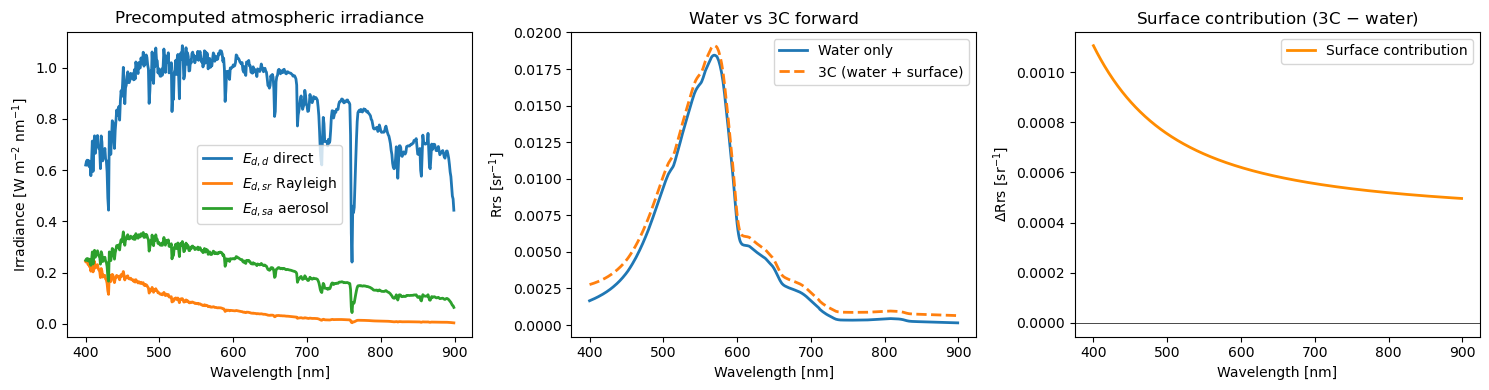


Rrs @ 550 nm — water: 0.01649  |  3C: 0.01716  |  surface: 0.00067 sr-1


In [19]:
from bio_optics.coupled_models import albert_mobley_3C_jax

# --- Build 3C parameter set ---
params_3C = params.copy()
params_3C['theta_view'].value = np.radians(2)
params_3C.add('fd_d',   value=1.0,   vary=False)   # fraction of direct irradiance
params_3C.add('fd_s',   value=1.0,   vary=False)   # fraction of diffuse irradiance
params_3C.add('g_dd',   value=0.02,  vary=False)   # direct sun glint factor     [sr-1]
params_3C.add('g_dsr',  value=0.15,  vary=False)   # Rayleigh sky glint factor   [sr-1]
params_3C.add('g_dsa',  value=0.05,  vary=False)   # aerosol sky glint factor    [sr-1]
params_3C.add('d_r',    value=0.0,   vary=False)   # residual offset             [sr-1]
params_3C.add('offset', value=0.0,   vary=False)   # additive offset             [sr-1]

# --- Precompute water IOPs + atmospheric irradiance ---
pre_3C = albert_mobley_3C_jax.precompute(
    wavelengths,
    theta_sun=float(params['theta_sun']),
)

# --- Base Rrs from both models ---
Rrs_water = np.array(albert_mobley_jax.forward(params_3C, pre_3C))
Rrs_3C    = np.array(albert_mobley_3C_jax.forward(params_3C, pre_3C))
Rrs_surf  = Rrs_3C - Rrs_water

# --- Three-panel overview ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(wavelengths, pre_3C['Ed_d'],  lw=2, label='$E_{d,d}$ direct')
ax.plot(wavelengths, pre_3C['Ed_sr'], lw=2, label='$E_{d,sr}$ Rayleigh')
ax.plot(wavelengths, pre_3C['Ed_sa'], lw=2, label='$E_{d,sa}$ aerosol')
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Irradiance [W m$^{-2}$ nm$^{-1}$]')
ax.set_title('Precomputed atmospheric irradiance')
ax.legend()

ax = axes[1]
ax.plot(wavelengths, Rrs_water, lw=2, label='Water only')
ax.plot(wavelengths, Rrs_3C,   lw=2, ls='--', label='3C (water + surface)')
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Rrs [sr$^{-1}$]')
ax.set_title('Water vs 3C forward')
ax.legend()

ax = axes[2]
ax.plot(wavelengths, Rrs_surf, lw=2, color='darkorange', label='Surface contribution')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('$\Delta$Rrs [sr$^{-1}$]')
ax.set_title('Surface contribution (3C $-$ water)')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nRrs @ 550 nm — water: {Rrs_water[150]:.5f}  |  3C: {Rrs_3C[150]:.5f}  |  surface: {Rrs_surf[150]:.5f} sr-1")

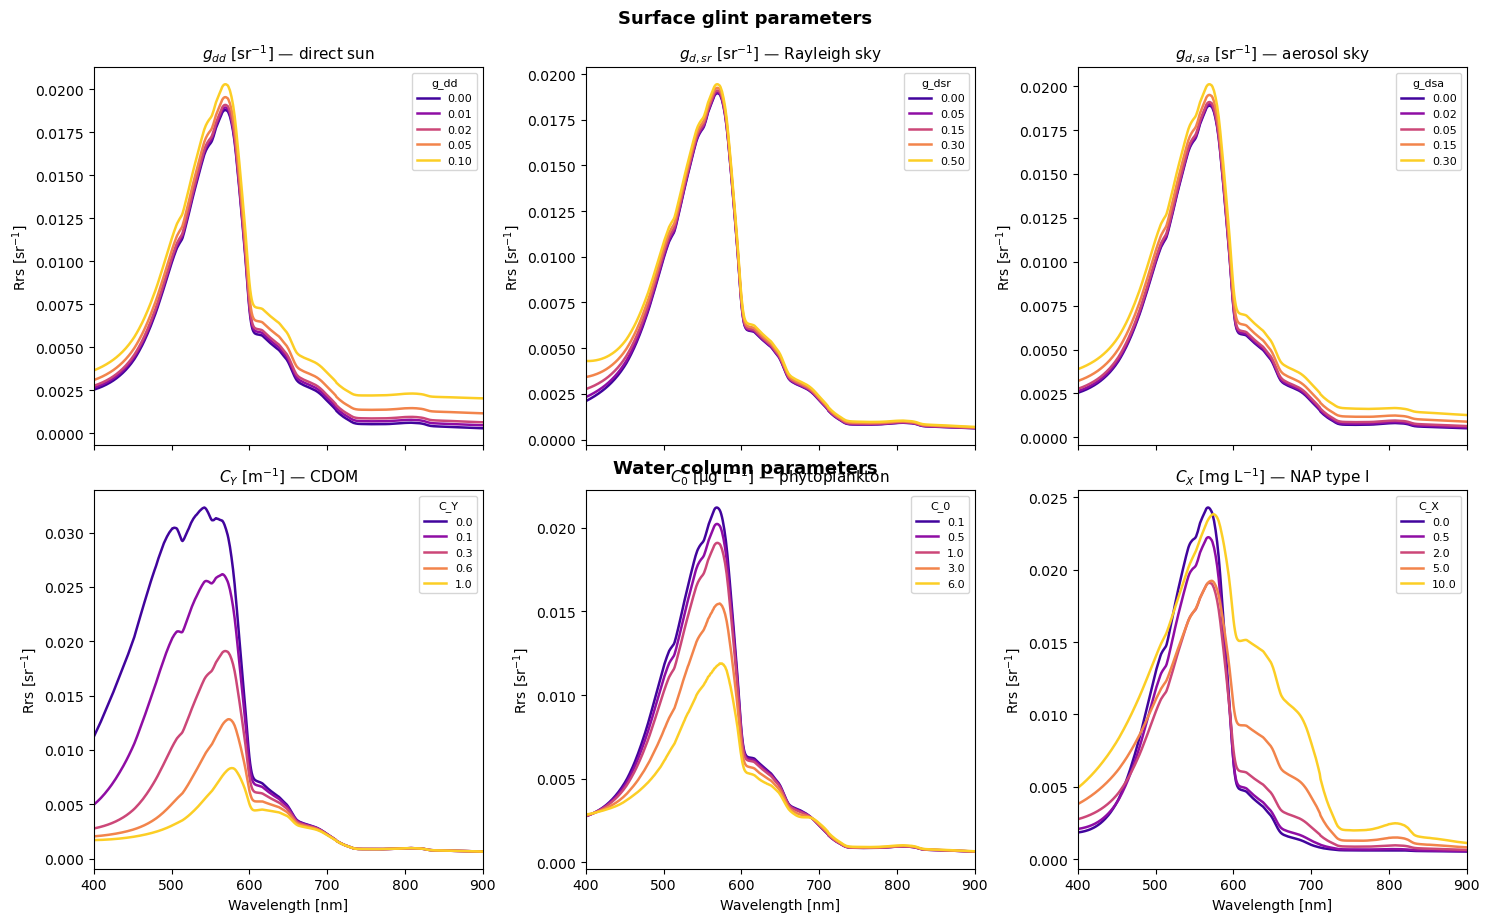

In [20]:
# Parameter sweep: glint params (top row) vs water params (bottom row)
# Each panel shows Rrs as one parameter is varied while all others are held at default.

p_base = {k: float(v) for k, v in params_3C.items()}

def sweep(param_name, values, fmt='{:.2f}'):
    results = []
    for v in values:
        p = dict(p_base)
        p[param_name] = float(v)
        Rrs = np.array(albert_mobley_3C_jax._forward_core(p, pre_3C))
        results.append((fmt.format(v), Rrs))
    return results

sweeps = [
    ('g_dd',  [0.0, 0.01, 0.02, 0.05, 0.10],  '{:.2f}', '$g_{dd}$ [sr$^{-1}$] — direct sun'),
    ('g_dsr', [0.0, 0.05, 0.15, 0.30, 0.50],  '{:.2f}', '$g_{d,sr}$ [sr$^{-1}$] — Rayleigh sky'),
    ('g_dsa', [0.0, 0.02, 0.05, 0.15, 0.30],  '{:.2f}', '$g_{d,sa}$ [sr$^{-1}$] — aerosol sky'),
    ('C_Y',   [0.0, 0.1,  0.3,  0.6,  1.0],   '{:.1f}', '$C_Y$ [m$^{-1}$] — CDOM'),
    ('C_0',   [0.1, 0.5,  1.0,  3.0,  6.0],   '{:.1f}', '$C_0$ [µg L$^{-1}$] — phytoplankton'),
    ('C_X',   [0.0, 0.5,  2.0,  5.0, 10.0],   '{:.1f}', '$C_X$ [mg L$^{-1}$] — NAP type I'),
]

colors = plt.cm.plasma(np.linspace(0.1, 0.9, 5))

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True)

for ax, (pname, vals, fmt, title) in zip(axes.flatten(), sweeps):
    for (label, Rrs), c in zip(sweep(pname, vals, fmt), colors):
        ax.plot(wavelengths, Rrs, color=c, lw=1.8, label=label)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Rrs [sr$^{-1}$]')
    ax.set_xlim(400, 900)
    ax.legend(fontsize=8, title=pname, title_fontsize=8)

for ax in axes[1]:
    ax.set_xlabel('Wavelength [nm]')

fig.text(0.5, 1.00, 'Surface glint parameters', ha='center', va='bottom', fontsize=13, fontweight='bold')
fig.text(0.5, 0.50, 'Water column parameters', ha='center', va='bottom', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

3C Jacobian shape: (500, 50)  (n_wavelengths × n_params)


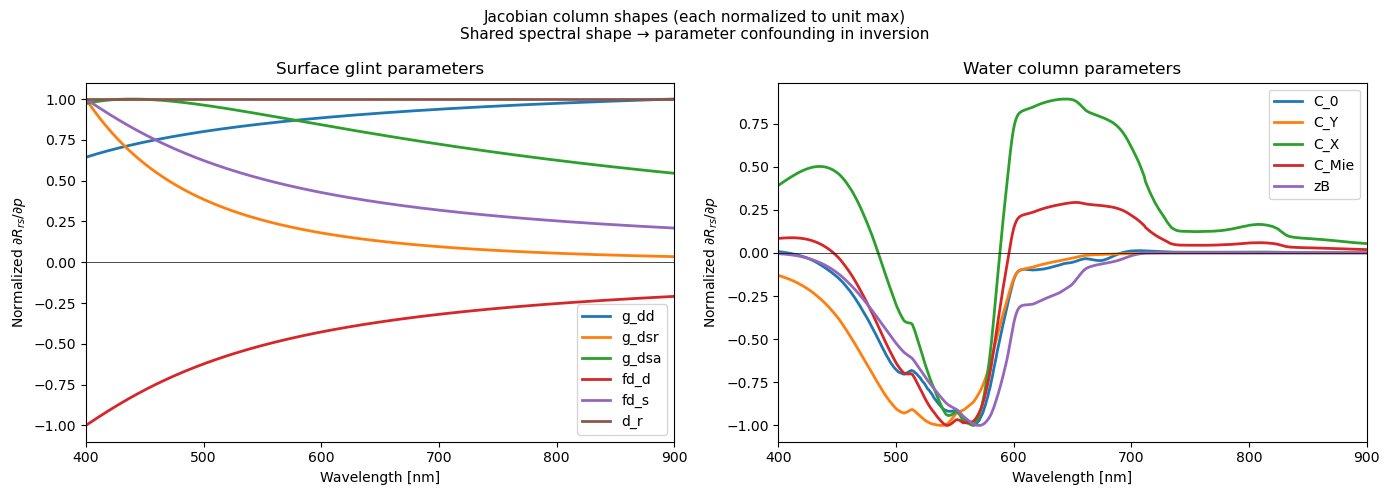

In [21]:
# Jacobian of the 3C model — normalized column shapes reveal confounding structure.
# If dRrs/d(g_dsr) looks like dRrs/d(C_Y), those two parameters are spectrally degenerate.

all_names_3C  = list(params_3C.keys())
params_vec_3C = jnp.array([float(params_3C[k]) for k in all_names_3C])

f_vec_3C = albert_mobley_3C_jax.make_forward_vec(all_names_3C, pre_3C)
f_jit_3C = jax.jit(f_vec_3C)
_ = f_jit_3C(params_vec_3C).block_until_ready()  # warm-up

J3C = jax.jacobian(f_jit_3C)(params_vec_3C)
print(f"3C Jacobian shape: {J3C.shape}  (n_wavelengths × n_params)")

# --- Plot normalized sensitivity shapes ---
surface_params = ['g_dd', 'g_dsr', 'g_dsa', 'fd_d', 'fd_s', 'd_r']
water_params   = ['C_0', 'C_Y', 'C_X', 'C_Mie', 'zB']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, param_list, title in [
    (axes[0], surface_params, 'Surface glint parameters'),
    (axes[1], water_params,   'Water column parameters'),
]:
    for name in param_list:
        idx  = all_names_3C.index(name)
        col  = np.array(J3C[:, idx])
        scale = np.max(np.abs(col)) + 1e-15
        ax.plot(wavelengths, col / scale, lw=2, label=name)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel('Wavelength [nm]')
    ax.set_ylabel('Normalized $\partial R_{rs}/\partial p$')
    ax.set_xlim(400, 900)
    ax.set_title(title)
    ax.legend()

fig.suptitle(
    'Jacobian column shapes (each normalized to unit max)\n'
    'Shared spectral shape → parameter confounding in inversion',
    fontsize=11,
)
plt.tight_layout()
plt.show()

## 8  Analytic uncertainty & confounding (OE theory, no inversion needed)

We already have the Jacobian $\mathbf{J}$ (shape $n_\lambda \times n_p$). That is everything needed for a complete analytic OE uncertainty analysis — no pixel fitting required.

### The three ingredients

| Symbol | Name | What it encodes |
|---|---|---|
| $S_\varepsilon$ | Measurement noise covariance | Instrument noise + residual atmospheric errors |
| $S_a$ | Prior covariance | How uncertain are the parameters *before* seeing the spectrum? |
| $\mathbf{J}$ | Jacobian | Spectral fingerprint of each parameter (already computed above) |

### The OE posterior covariance

$$\hat{S} = \left(\mathbf{J}^\top S_\varepsilon^{-1} \mathbf{J} + S_a^{-1}\right)^{-1}$$

$\mathbf{J}^\top S_\varepsilon^{-1} \mathbf{J}$ is the **Fisher information** the spectrum carries about the parameters. Adding $S_a^{-1}$ regularises the ill-posed problem with prior knowledge.

### Three diagnostic outputs

**1. Posterior standard deviation** $\hat{\sigma}_i = \sqrt{\hat{S}_{ii}}$  
The retrieval uncertainty on parameter $i$ after fitting. If $\hat{\sigma}_i \approx \sigma_{a,i}$, the spectrum carries no information about that parameter — you are getting back your prior.

**2. Correlation matrix** $R_{ij} = \hat{S}_{ij}/(\hat{\sigma}_i\hat{\sigma}_j) \in [-1, 1]$  
Values near $\pm 1$ mean the measurement cannot distinguish parameters $i$ and $j$. A large $|R[g_{d,sr}, C_Y]|$ is the quantitative fingerprint of the sky-glint / CDOM degeneracy.

**3. Averaging kernel** $A = \hat{S}\,\mathbf{J}^\top S_\varepsilon^{-1}\mathbf{J}$  
Diagonal element $A_{ii} \in [0,1]$ tells you how much of the retrieved value for parameter $i$ comes from the *measurement* ($A_{ii} \to 1$) versus being pulled toward the *prior* ($A_{ii} \to 0$). $\text{tr}(A)$ = degrees of freedom for signal (DFS) = how many independent parameters the spectrum actually constrains.

### Key insight for the skeptic

The confounding is **not a fixed number** — it depends on $S_a$. If you constrain $g_{d,sr}$ tightly (sky camera, clear-water neighbour pixel, ancillary model), the posterior uncertainty on $C_Y$ decreases. The sensitivity curve $\hat{\sigma}(C_Y)$ vs $\sigma_a(g_{d,sr})$ is the quantitative answer to *"how much does my glint correction uncertainty affect my CDOM retrieval?"*

In [22]:
# Parameters that would realistically be retrieved in an inversion.
# Fixed params (n1, n2, T_W, theta_sun, etc.) are excluded.
# 'offset' is excluded because it is perfectly degenerate with 'd_r'.
fit_params = ['C_0', 'C_Y', 'C_X', 'C_Mie', 'zB',
              'g_dd', 'g_dsr', 'g_dsa', 'fd_d', 'fd_s', 'd_r']

# Prior standard deviations — what we know before seeing the spectrum.
# These should reflect realistic parameter ranges, not instrument precision.
sigma_a_vals = {
    'C_0':   3.0,    # µg/L    phytoplankton, range ~0.1–10
    'C_Y':   0.5,    # m-1     CDOM, range ~0–2
    'C_X':   5.0,    # mg/L    NAP type I, range ~0–20
    'C_Mie': 2.0,    # mg/L    NAP type II, range ~0–5
    'zB':    5.0,    # m       depth, range ~0–20
    'g_dd':  0.02,   # sr-1    direct sun glint factor — tight
    'g_dsr': 0.15,   # sr-1    Rayleigh glint factor — moderate
    'g_dsa': 0.05,   # sr-1    aerosol glint factor — tight
    'fd_d':  0.3,    #         fraction of direct irradiance
    'fd_s':  0.3,    #         fraction of diffuse irradiance
    'd_r':   0.002,  # sr-1    residual offset
}
sigma_a = np.array([sigma_a_vals[p] for p in fit_params])

# Measurement noise S_epsilon: 1% relative noise with a floor of 1e-5 sr-1.
# Adjust SNR to reflect your instrument / processing quality.
snr       = 100
sigma_eps = np.maximum(Rrs_3C / snr, 1e-5)
S_eps_inv = np.diag(1.0 / sigma_eps**2)

# Extract Jacobian columns for the fitted parameters only.
idx_fit = [all_names_3C.index(p) for p in fit_params]
J_fit   = np.array(J3C[:, idx_fit])           # shape (n_wl, n_fit)

# Prior covariance inverse (diagonal).
S_a_inv = np.diag(1.0 / sigma_a**2)

# --- OE posterior covariance ---
F     = J_fit.T @ S_eps_inv @ J_fit + S_a_inv  # Fisher / Hessian (n_fit, n_fit)
S_hat = np.linalg.inv(F)                        # posterior covariance

# --- Derived diagnostics ---
sigma_post = np.sqrt(np.diag(S_hat))
R   = S_hat / np.outer(sigma_post, sigma_post)  # correlation matrix
A   = S_hat @ J_fit.T @ S_eps_inv @ J_fit       # averaging kernel
dfs = np.trace(A)                               # degrees of freedom for signal

print(f"Degrees of freedom for signal (DFS): {dfs:.1f} / {len(fit_params)}")
print(f"  → the spectrum independently constrains ~{dfs:.0f} parameter combinations\n")
print(f"{'Parameter':<10}  {'σ_prior':>8}  {'σ_post':>8}  {'σ_post/σ_prior':>14}  {'A_ii':>6}")
print("-" * 56)
for i, p in enumerate(fit_params):
    flag = " ← prior-dominated" if sigma_post[i] / sigma_a[i] > 0.9 else ""
    print(f"{p:<10}  {sigma_a[i]:>8.4f}  {sigma_post[i]:>8.4f}  {sigma_post[i]/sigma_a[i]:>14.3f}  {A[i,i]:>6.3f}{flag}")

i_g = fit_params.index('g_dsr')
i_Y = fit_params.index('C_Y')
print(f"\nKey confounding:  R[g_dsr, C_Y] = {R[i_g, i_Y]:.3f}")

Degrees of freedom for signal (DFS): 8.0 / 11
  → the spectrum independently constrains ~8 parameter combinations

Parameter    σ_prior    σ_post  σ_post/σ_prior    A_ii
--------------------------------------------------------
C_0           3.0000    0.0715           0.024   0.999
C_Y           0.5000    0.0076           0.015   1.000
C_X           5.0000    0.2090           0.042   0.998
C_Mie         2.0000    0.4186           0.209   0.956
zB            5.0000    0.0140           0.003   1.000
g_dd          0.0200    0.0182           0.912   0.167 ← prior-dominated
g_dsr         0.1500    0.0278           0.186   0.966
g_dsa         0.0500    0.0216           0.432   0.813
fd_d          0.3000    0.2898           0.966   0.067 ← prior-dominated
fd_s          0.3000    0.2898           0.966   0.067 ← prior-dominated
d_r           0.0020    0.0004           0.183   0.967

Key confounding:  R[g_dsr, C_Y] = -0.074


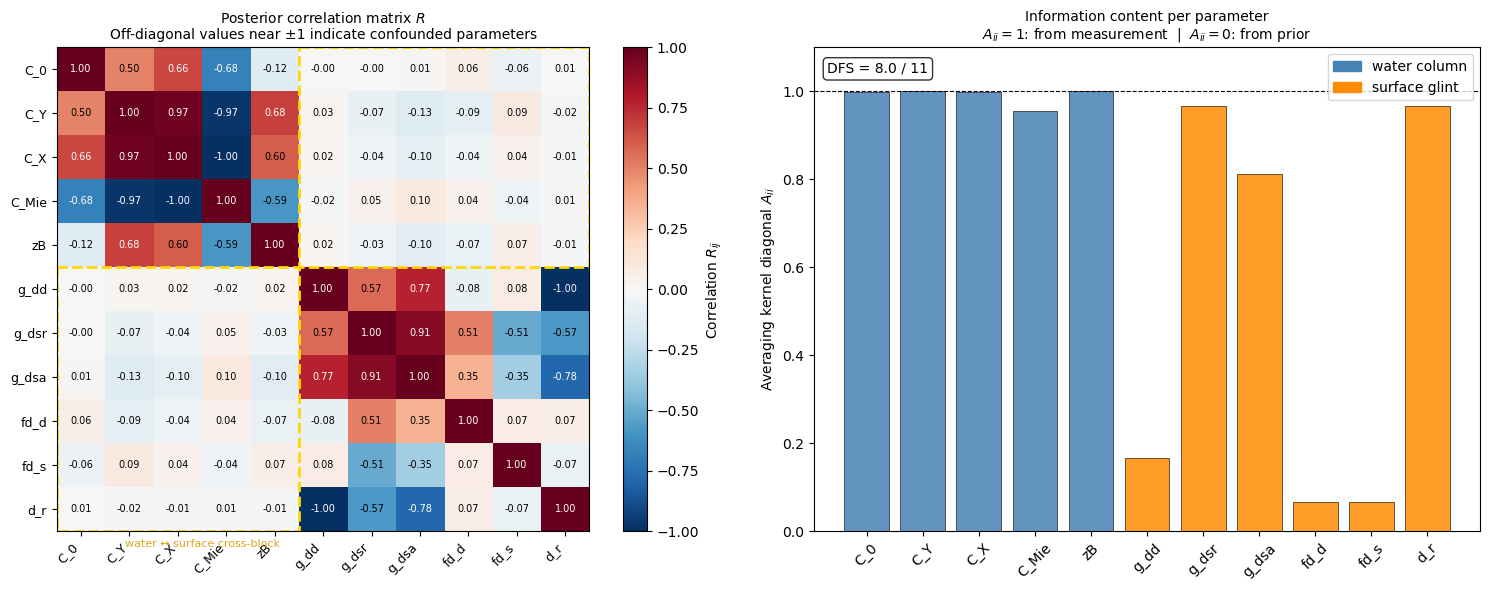

In [23]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Left: posterior correlation matrix ---
ax = axes[0]
im = ax.imshow(R, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
ax.set_xticks(range(len(fit_params)))
ax.set_yticks(range(len(fit_params)))
ax.set_xticklabels(fit_params, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(fit_params, fontsize=9)
for i in range(len(fit_params)):
    for j in range(len(fit_params)):
        txt_color = 'w' if abs(R[i, j]) > 0.65 else 'k'
        ax.text(j, i, f'{R[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color=txt_color)
plt.colorbar(im, ax=ax, label='Correlation $R_{ij}$')
ax.set_title('Posterior correlation matrix $R$\n'
             'Off-diagonal values near ±1 indicate confounded parameters', fontsize=10)

# Draw a box around the water/surface cross-block
n_water = 5  # C_0, C_Y, C_X, C_Mie, zB
n_surf  = len(fit_params) - n_water
from matplotlib.patches import Rectangle
rect = Rectangle((-0.5, n_water - 0.5), n_water, n_surf,
                 fill=False, edgecolor='gold', lw=2, linestyle='--')
ax.add_patch(rect)
rect2 = Rectangle((n_water - 0.5, -0.5), n_surf, n_water,
                  fill=False, edgecolor='gold', lw=2, linestyle='--')
ax.add_patch(rect2)
ax.text(n_water / 2, len(fit_params) - 0.1, 'water ↔ surface cross-block',
        ha='center', va='bottom', color='goldenrod', fontsize=8)

# --- Right: averaging kernel diagonal ---
ax = axes[1]
bar_colors = ['steelblue'] * 5 + ['darkorange'] * 6
ax.bar(fit_params, np.diag(A), color=bar_colors, alpha=0.85, edgecolor='k', lw=0.5)
ax.axhline(1.0, color='k', lw=0.8, ls='--', label='fully measurement-driven ($A_{ii}=1$)')
ax.set_ylabel('Averaging kernel diagonal $A_{ii}$', fontsize=10)
ax.set_title('Information content per parameter\n'
             '$A_{ii}=1$: from measurement  |  $A_{ii}=0$: from prior', fontsize=10)
ax.set_ylim(0, 1.1)
ax.tick_params(axis='x', rotation=45)
ax.legend(handles=[
    Patch(color='steelblue',   label='water column'),
    Patch(color='darkorange',  label='surface glint'),
], loc='upper right')
ax.text(0.02, 0.97, f'DFS = {dfs:.1f} / {len(fit_params)}',
        transform=ax.transAxes, va='top', fontsize=10,
        bbox=dict(boxstyle='round', fc='white', alpha=0.8))

plt.tight_layout()
plt.show()

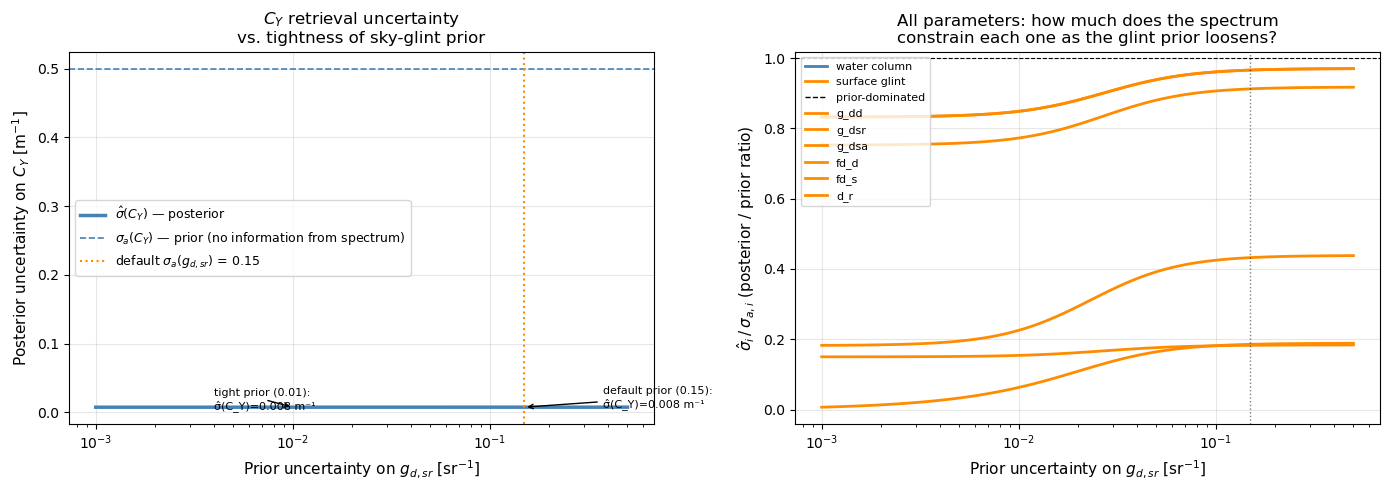

Summary:
  Tight g_dsr prior (σ=0.01 sr⁻¹):    σ̂(C_Y) = 0.008 m⁻¹
  Default g_dsr prior (σ=0.15 sr⁻¹): σ̂(C_Y) = 0.008 m⁻¹
  No g_dsr constraint (σ→∞ proxy):     σ̂(C_Y) = 0.008 m⁻¹  (≈ prior 0.50)


In [24]:
# Sweep sigma_a(g_dsr) from very tight to very loose and record how all
# fitted parameters' posterior uncertainties change.
# This is the quantitative answer to "how much does my glint correction
# uncertainty propagate into my water quality retrievals?"

idx_g_dsr = fit_params.index('g_dsr')
idx_C_Y   = fit_params.index('C_Y')

sigma_g_dsr_range = np.logspace(-3, np.log10(0.5), 80)
all_sigma_post    = np.zeros((len(fit_params), len(sigma_g_dsr_range)))

for j, sg in enumerate(sigma_g_dsr_range):
    sa_tmp = sigma_a.copy()
    sa_tmp[idx_g_dsr] = sg
    F_tmp       = J_fit.T @ S_eps_inv @ J_fit + np.diag(1.0 / sa_tmp**2)
    all_sigma_post[:, j] = np.sqrt(np.diag(np.linalg.inv(F_tmp)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: C_Y uncertainty vs g_dsr prior ---
ax = axes[0]
ax.semilogx(sigma_g_dsr_range, all_sigma_post[idx_C_Y], lw=2.5, color='steelblue',
            label=r'$\hat{\sigma}(C_Y)$ — posterior')
ax.axhline(sigma_a[idx_C_Y], color='steelblue', lw=1.2, ls='--',
           label=r'$\sigma_a(C_Y)$ — prior (no information from spectrum)')
ax.axvline(sigma_a_vals['g_dsr'], color='darkorange', lw=1.5, ls=':',
           label=f"default $\\sigma_a(g_{{d,sr}})$ = {sigma_a_vals['g_dsr']}")
ax.set_xlabel(r'Prior uncertainty on $g_{d,sr}$ [sr$^{-1}$]', fontsize=11)
ax.set_ylabel(r'Posterior uncertainty on $C_Y$ [m$^{-1}$]', fontsize=11)
ax.set_title('$C_Y$ retrieval uncertainty\nvs. tightness of sky-glint prior')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Annotate the reduction
idx_tight   = np.argmin(np.abs(sigma_g_dsr_range - 0.01))
idx_default = np.argmin(np.abs(sigma_g_dsr_range - sigma_a_vals['g_dsr']))
ax.annotate(f"tight prior (0.01):\nσ̂(C_Y)={all_sigma_post[idx_C_Y, idx_tight]:.3f} m⁻¹",
            xy=(0.01, all_sigma_post[idx_C_Y, idx_tight]),
            xytext=(0.004, all_sigma_post[idx_C_Y, idx_tight] * 0.7),
            arrowprops=dict(arrowstyle='->', color='k'), fontsize=8)
ax.annotate(f"default prior ({sigma_a_vals['g_dsr']}):\nσ̂(C_Y)={all_sigma_post[idx_C_Y, idx_default]:.3f} m⁻¹",
            xy=(sigma_a_vals['g_dsr'], all_sigma_post[idx_C_Y, idx_default]),
            xytext=(sigma_a_vals['g_dsr'] * 2.5, all_sigma_post[idx_C_Y, idx_default] * 1.1),
            arrowprops=dict(arrowstyle='->', color='k'), fontsize=8)

# --- Right: all parameters affected by g_dsr prior ---
ax = axes[1]
water_color = 'steelblue'
surf_color  = 'darkorange'
for i, p in enumerate(fit_params):
    arr = all_sigma_post[i] / sigma_a[i]   # posterior / prior ratio
    if arr.max() - arr.min() > 0.02:       # only show params that actually change
        color = water_color if p in ['C_0', 'C_Y', 'C_X', 'C_Mie', 'zB'] else surf_color
        ax.semilogx(sigma_g_dsr_range, arr, lw=2, color=color, label=p)

ax.axhline(1.0, color='k', lw=0.8, ls='--', label='prior-dominated ($\\hat{\\sigma}/\\sigma_a=1$)')
ax.axvline(sigma_a_vals['g_dsr'], color='k', lw=1, ls=':', alpha=0.5)
ax.set_xlabel(r'Prior uncertainty on $g_{d,sr}$ [sr$^{-1}$]', fontsize=11)
ax.set_ylabel(r'$\hat{\sigma}_i\,/\,\sigma_{a,i}$ (posterior / prior ratio)', fontsize=11)
ax.set_title('All parameters: how much does the spectrum\nconstrain each one as the glint prior loosens?')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], color=water_color, lw=2, label='water column'),
    Line2D([0], [0], color=surf_color,  lw=2, label='surface glint'),
    Line2D([0], [0], color='k', lw=1, ls='--', label='prior-dominated'),
] + [Line2D([0], [0], color=('steelblue' if p in ['C_0','C_Y','C_X','C_Mie','zB'] else 'darkorange'),
             lw=2, label=p)
     for i, p in enumerate(fit_params)
     if (all_sigma_post[i] / sigma_a[i]).ptp() > 0.02],
    fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

print("Summary:")
print(f"  Tight g_dsr prior (σ=0.01 sr⁻¹):    σ̂(C_Y) = {all_sigma_post[idx_C_Y, idx_tight]:.3f} m⁻¹")
print(f"  Default g_dsr prior (σ={sigma_a_vals['g_dsr']} sr⁻¹): σ̂(C_Y) = {all_sigma_post[idx_C_Y, idx_default]:.3f} m⁻¹")
print(f"  No g_dsr constraint (σ→∞ proxy):     σ̂(C_Y) = {all_sigma_post[idx_C_Y, -1]:.3f} m⁻¹  (≈ prior {sigma_a[idx_C_Y]:.2f})")

## 9  bi vs bi_jax — numerical equivalence

`bi_jax` is the JAX reimplementation of the HEREON water optical model (`bi.py`, Bi et al. 2023).
Both accept the same lmfit Parameters and should produce identical spectra within float64 precision.

In [25]:
from bio_optics.water.reflectance import bi, bi_jax

# --- parameters (same as NB15 / NB18) ---------------------------------------
params_bi = lmfit.Parameters()

params_bi.add('C_0',   value=2.0,  vary=False)
params_bi.add('C_1',   value=1.0,  vary=False)
params_bi.add('C_2',   value=0.5,  vary=False)
params_bi.add('C_3',   value=0.0,  vary=False)
params_bi.add('C_4',   value=0.0,  vary=False)
params_bi.add('C_5',   value=0.0,  vary=False)
params_bi.add('C_6',   value=0.0,  vary=False)
params_bi.add('C_7',   value=0.0,  vary=False)
params_bi.add('C_Y',   value=0.3,  vary=False)
params_bi.add('C_ism', value=5.0,  vary=False)
params_bi.add('offset',value=0.0,  vary=False)

params_bi.add('S_cdom',        value=0.014, vary=False)
params_bi.add('lambda_0_cdom', value=440.0, vary=False)
params_bi.add('K',             value=0.0,   vary=False)

params_bi.add('A_md',        value=0.04,  vary=False)
params_bi.add('S_md',        value=0.011, vary=False)
params_bi.add('C_md',        value=0.0,   vary=False)
params_bi.add('lambda_0_md', value=440.0, vary=False)

params_bi.add('A_bd',        value=0.001, vary=False)
params_bi.add('S_bd',        value=0.011, vary=False)
params_bi.add('C_bd',        value=0.0,   vary=False)
params_bi.add('lambda_0_bd', value=440.0, vary=False)

params_bi.add('gamma_d',     value=0.5,   vary=False)
params_bi.add('x0',          value=0.96,  vary=False)
params_bi.add('x1',          value=0.5,   vary=False)
params_bi.add('x2',          value=1.0,   vary=False)
params_bi.add('lambda_0_c_d',value=550.0, vary=False)

params_bi.add('T_W',   value=15.0, vary=False)
params_bi.add('T_W_0', value=15.0, vary=False)

# bi.py uses 'A' for the phytoplankton packaging correction; bi_jax calls it 'A_phy'
params_bi.add('A',             value=0.06,  vary=False)
params_bi.add('A_phy',         value=0.06,  vary=False)
params_bi.add('E0',            value=0.65,  vary=False)
params_bi.add('E1',            value=0.67,  vary=False)
params_bi.add('lambda_0_phy',  value=440.0, vary=False)

for i in range(8):
    params_bi.add(f'b_ratio_C_{i}', value=0.01, vary=False)
params_bi.add('b_ratio_md', value=0.02, vary=False)
params_bi.add('b_ratio_bd', value=0.01, vary=False)

params_bi.add('Gw0', value=0.0895, vary=False)
params_bi.add('Gw1', value=0.1247, vary=False)
params_bi.add('Gp0', value=0.0401, vary=False)
params_bi.add('Gp1', value=0.0841, vary=False)

params_bi.add('n2',          value=1.333, vary=False)
params_bi.add('interpolate', value=True,  vary=False)
params_bi.add('fresh',       value=False,  vary=False)

# --- precompute for bi_jax --------------------------------------------------
wl_bi  = np.arange(400, 901, dtype=float)
pre_bi = bi_jax.precompute(wl_bi)

print(f'Wavelength range : {wl_bi[0]:.0f} – {wl_bi[-1]:.0f} nm  ({len(wl_bi)} bands)')

Wavelength range : 400 – 900 nm  (501 bands)


Max absolute difference : 1.08e-18  sr-1
Max relative difference : 6.62e-16
PASSED: bi and bi_jax agree within 1e-6 sr-1


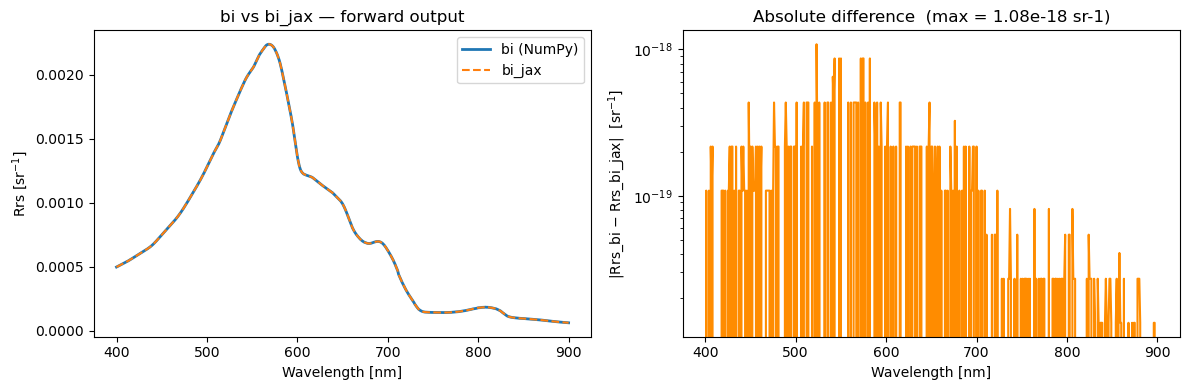

In [26]:
# --- call both forward models -----------------------------------------------
Rrs_bi_np  = np.array(bi.forward(params_bi, wl_bi))
Rrs_bi_jax = np.array(bi_jax.forward(params_bi, pre_bi))

max_abs_diff = np.max(np.abs(Rrs_bi_np - Rrs_bi_jax))
rel_diff     = np.max(np.abs((Rrs_bi_np - Rrs_bi_jax) / (np.abs(Rrs_bi_np) + 1e-12)))

print(f'Max absolute difference : {max_abs_diff:.2e}  sr-1')
print(f'Max relative difference : {rel_diff:.2e}')
if max_abs_diff < 1e-6:
    print('PASSED: bi and bi_jax agree within 1e-6 sr-1')
else:
    print('FAILED: outputs differ — investigate below')

# --- plot -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(wl_bi, Rrs_bi_np,  lw=2,        label='bi (NumPy)')
axes[0].plot(wl_bi, Rrs_bi_jax, lw=1.5, ls='--', label='bi_jax')
axes[0].set_xlabel('Wavelength [nm]')
axes[0].set_ylabel('Rrs [sr$^{-1}$]')
axes[0].set_title('bi vs bi_jax — forward output')
axes[0].legend()

diff = np.abs(Rrs_bi_np - Rrs_bi_jax)
axes[1].plot(wl_bi, diff, color='darkorange')
axes[1].set_xlabel('Wavelength [nm]')
axes[1].set_ylabel('|Rrs_bi − Rrs_bi_jax|  [sr$^{-1}$]')
axes[1].set_title(f'Absolute difference  (max = {max_abs_diff:.2e} sr-1)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()